<a href="https://colab.research.google.com/github/DanielSotade/Chronic_Disease/blob/main/Chronic_Diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this section, I loaded the raw chronic disease dataset, cleaned the column headers to follow standard Snake Case formatting, removed observations with missing values in the target variable (numeric_value), and filtered out national-level collections (United States) to focus purely on state-level analysis.

In [3]:
import pandas as pd
url = 'https://raw.githubusercontent.com/DanielSotade/Chronic_Disease/main/chronic_disease_data.csv'
df = pd.read_csv(url)

df_clean = df.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df_clean = df_clean.dropna(subset=['numeric_value'])

text_cols = ['indicator_metric', 'measurement_type', 'state_name', 'state_code']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean['numeric_value'] = pd.to_numeric(df_clean['numeric_value'], errors='coerce')
df_clean = df_clean.dropna(subset=['numeric_value'])
df_clean = df_clean[df_clean['state_name'] != 'United States']

print(f"Original rows: {len(df)}")
print(f"Cleaned rows remaining: {len(df_clean)}")
print("\nCleaned Columns:\n", df_clean.columns.tolist())
display(df_clean.head())

Original rows: 43985
Cleaned rows remaining: 25171

Cleaned Columns:
 ['year', 'state_code', 'state_name', 'health_topic', 'indicator_metric', 'measurement_type', 'numeric_value', 'demographic_group']


,year,state_code,state_name,health_topic,indicator_metric,measurement_type,numeric_value,demographic_group
1,2019,CT,Connecticut,Cardiovascular Disease,High cholesterol among adults who have been sc...,Crude Prevalence,30.0,Hispanic
2,2019,DE,Delaware,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,38.8,"White, non-Hispanic"
3,2019,DE,Delaware,Cardiovascular Disease,Diseases of the heart mortality among all peop...,Number,2053.0,Overall
4,2019,DE,Delaware,Diabetes,Gestational diabetes among women with a recent...,Crude Prevalence,12.5,"White, non-Hispanic"
5,2019,GU,Guam,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,27.0,"Asian, non-Hispanic"


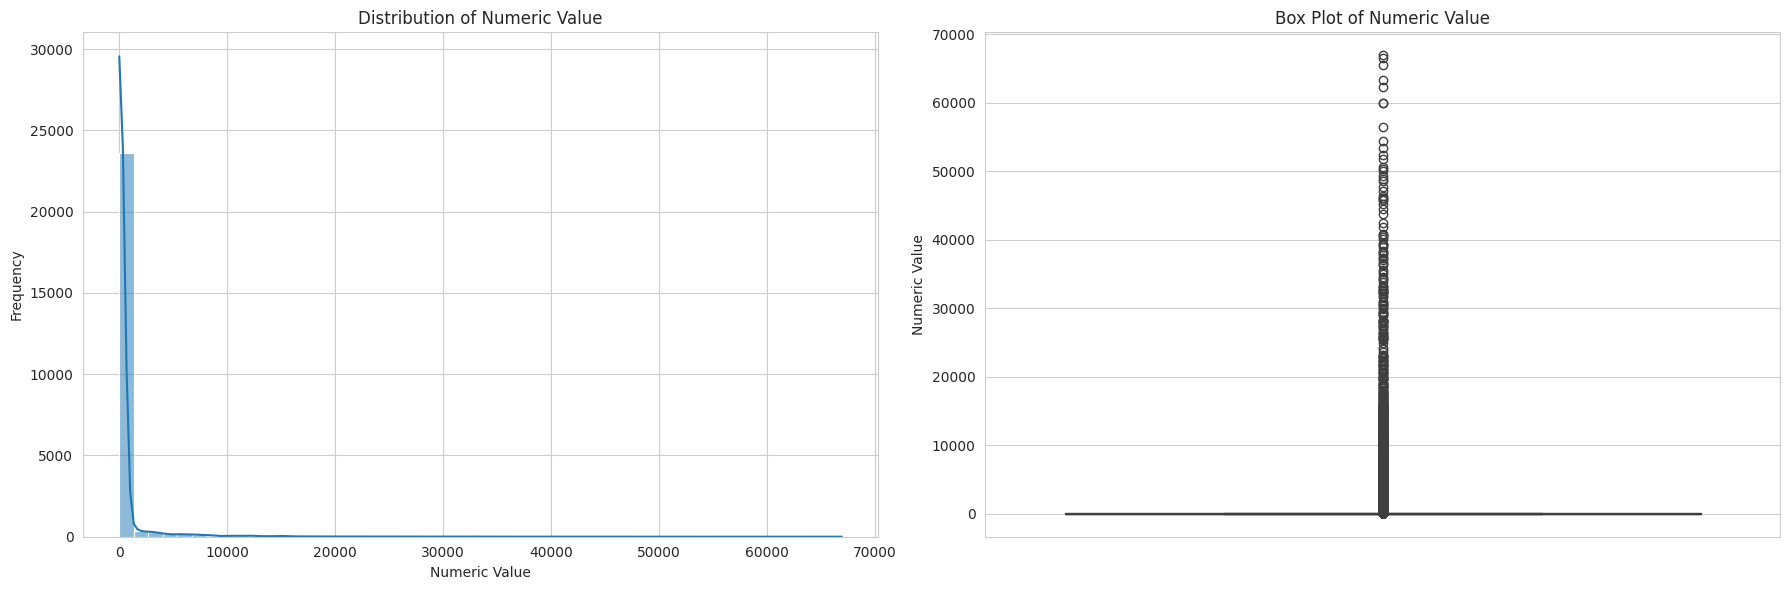

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram for 'numeric_value'
sns.histplot(df_clean['numeric_value'], kde=True, ax=axes[0], bins=50)
axes[0].set_title('Distribution of Numeric Value')
axes[0].set_xlabel('Numeric Value')
axes[0].set_ylabel('Frequency')

# Box plot for 'numeric_value'
sns.boxplot(y=df_clean['numeric_value'], ax=axes[1])
axes[1].set_title('Box Plot of Numeric Value')
axes[1].set_ylabel('Numeric Value')

plt.tight_layout()
plt.show()

## Distribution and Outlier Analysis

Spread & Distribution: The histogram shows that numeric_value is heavily right-skewed. Most observations are concentrated at lower values (between 0 and 30), while a much smaller number of observations extend to much higher values. This indicates that the dataset contains many relatively small prevalence or rate values and a smaller number of very large values.

Outliers: The box plot reveals numerous high-value outliers extending past the upper whisker. Since this dataset originates from CDC reporting systems, these extreme values are more likely to represent legitimate differences between health indicators, states, or measurement types rather than simple data entry errors. However, they should still be investigated before modeling because extreme values can influence averages and regression results.


--- State Name ---
Number of unique values: 54
Top 10 values and their counts:


,count
state_name,
Washington,675
New York,650
California,620
Arizona,611
Oklahoma,610
Michigan,609
Minnesota,603
Texas,595
Kansas,590


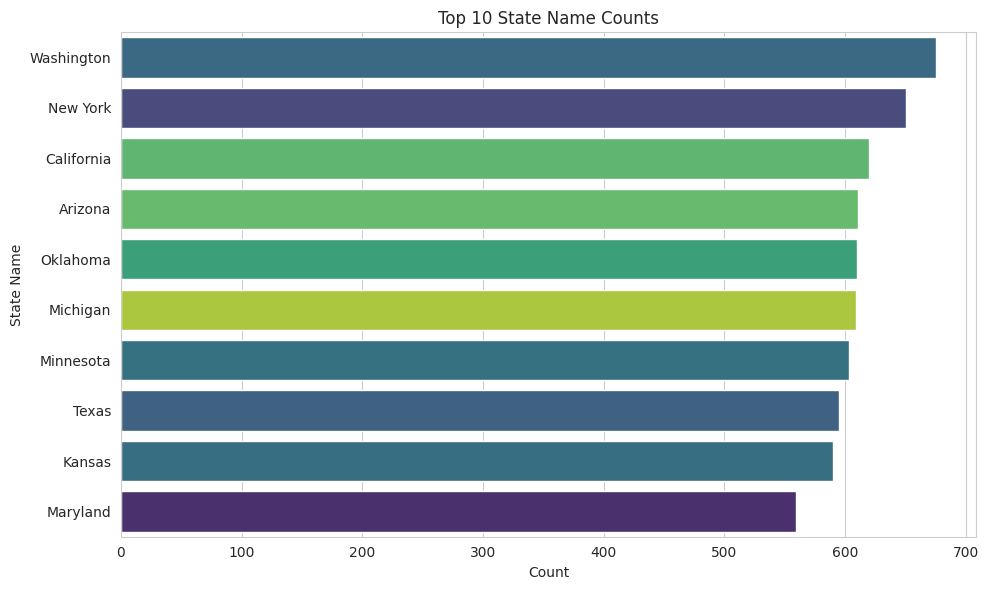


--- Health Topic ---
Number of unique values: 3
Top 10 values and their counts:


,count
health_topic,
Cardiovascular Disease,13644
Diabetes,6155
Tobacco,5372


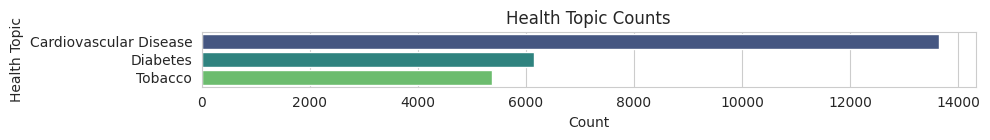


--- Indicator Metric ---
Number of unique values: 19
Top 10 values and their counts:


,count
indicator_metric,
"Diseases of the heart mortality among all people, underlying cause",2628
"Diabetes mortality among all people, underlying or contributing cause",2484
"Coronary heart disease mortality among all people, underlying cause",2328
"Hospitalization for heart failure as principal diagnosis, Medicare-beneficiaries aged 65 years and older",2205
Current cigarette smoking among adults,2190
"Cerebrovascular disease (stroke) mortality among all people, underlying cause",2049
Diabetes among adults,1994
Taking medicine for high cholesterol among adults,1194
High cholesterol among adults who have been screened,1192


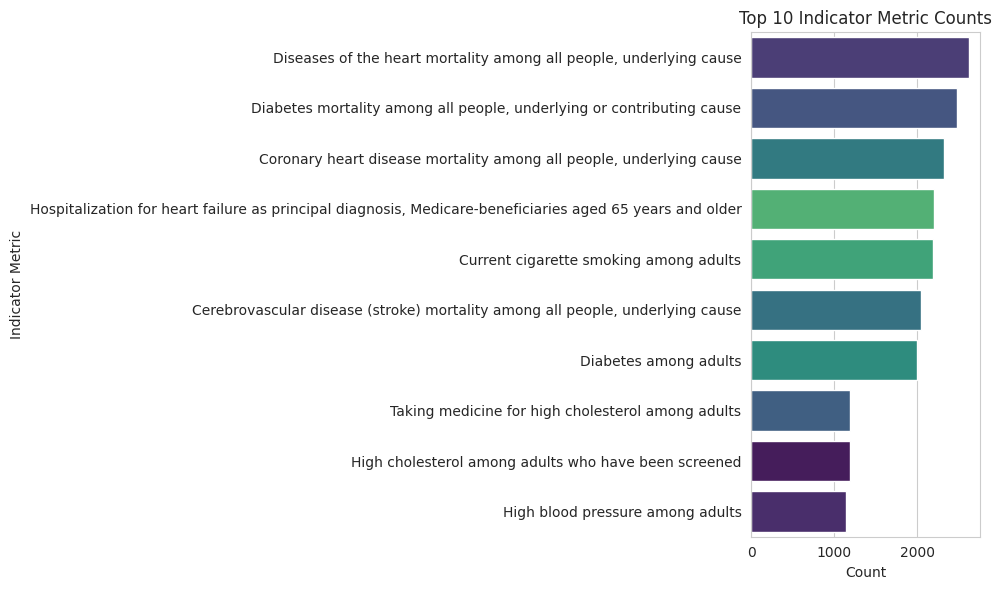


--- Measurement Type ---
Number of unique values: 6
Top 10 values and their counts:


,count
measurement_type,
Crude Prevalence,7368
Age-adjusted Prevalence,4850
Number,4264
Age-adjusted Rate,4264
Crude Rate,4264
Proportion,161


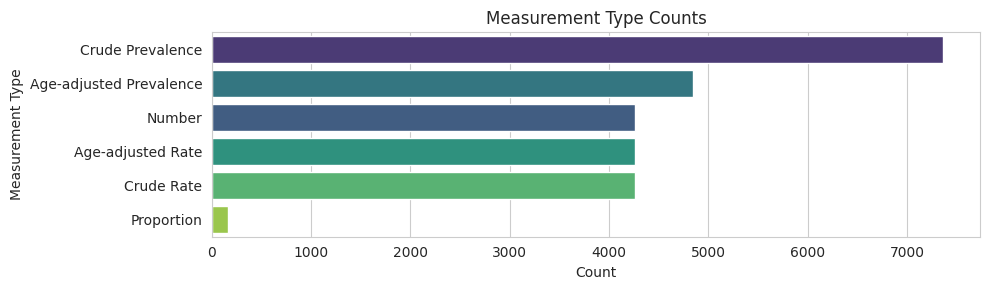


--- Demographic Group ---
Number of unique values: 9
Top 10 values and their counts:


,count
demographic_group,
Overall,5329
"White, non-Hispanic",5073
Hispanic,3928
"Black, non-Hispanic",3869
"Asian, non-Hispanic",2174
"Multiracial, non-Hispanic",2135
"American Indian or Alaska Native, non-Hispanic",1965
"Hawaiian or Pacific Islander, non-Hispanic",359
"Asian or Pacific Islander, non-Hispanic",339


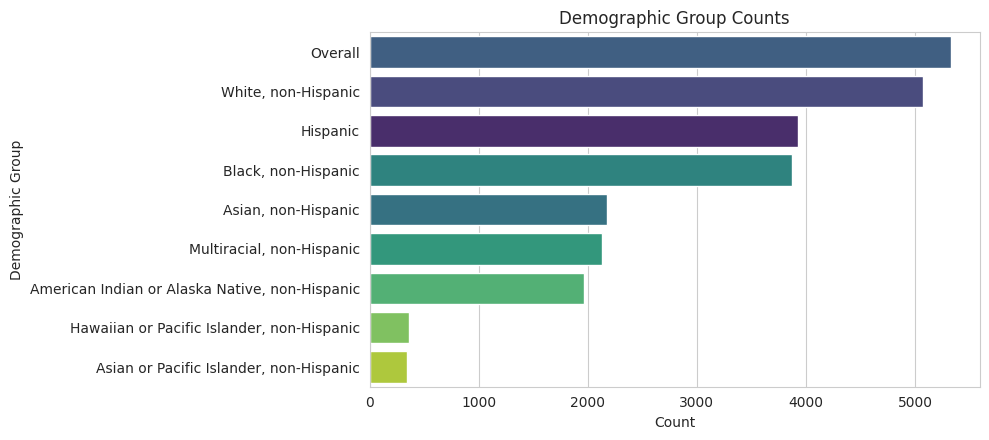

In [5]:
categorical_cols = ['state_name', 'health_topic', 'indicator_metric', 'measurement_type', 'demographic_group']

for col in categorical_cols:
    print(f"\n--- {col.replace('_', ' ').title()} ---")
    print(f"Number of unique values: {df_clean[col].nunique()}")
    print("Top 10 values and their counts:")
    display(df_clean[col].value_counts().head(10).to_frame())

    if df_clean[col].nunique() > 10:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=df_clean[col], order=df_clean[col].value_counts().index[:10], hue=df_clean[col], palette='viridis', legend=False)
        plt.title(f'Top 10 {col.replace("_", " ").title()} Counts')
        plt.xlabel('Count')
        plt.ylabel(col.replace("_", " ").title())
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(10, df_clean[col].nunique() * 0.5))
        sns.countplot(y=df_clean[col], order=df_clean[col].value_counts().index, hue=df_clean[col], palette='viridis', legend=False)
        plt.title(f'{col.replace("_", " ").title()} Counts')
        plt.xlabel('Count')
        plt.ylabel(col.replace("_", " ").title())
        plt.tight_layout()
        plt.show()

## Categorical Summary:
The dataset contains several categorical variables including state_name, health_topic, indicator_metric, measurement_type, and demographic_group. The variable indicator_metric contains the largest number of unique categories, representing highly granular health behaviors and outcomes. Conversely, variables like measurement_type contain relatively few, broader categories.

## Filtering Strategy:
 Because indicator_metric contains many different health measures that utilize entirely different units and scales (e.g., crude rates vs. age-adjusted percentages), comparing them directly in a raw state is statistically flawed. To make subsequent modeling and comparisons meaningful, we will filter the dataset to focus on specific, paired behavioral risk factors and chronic disease outcomes, rather than combining unrelated measurements.

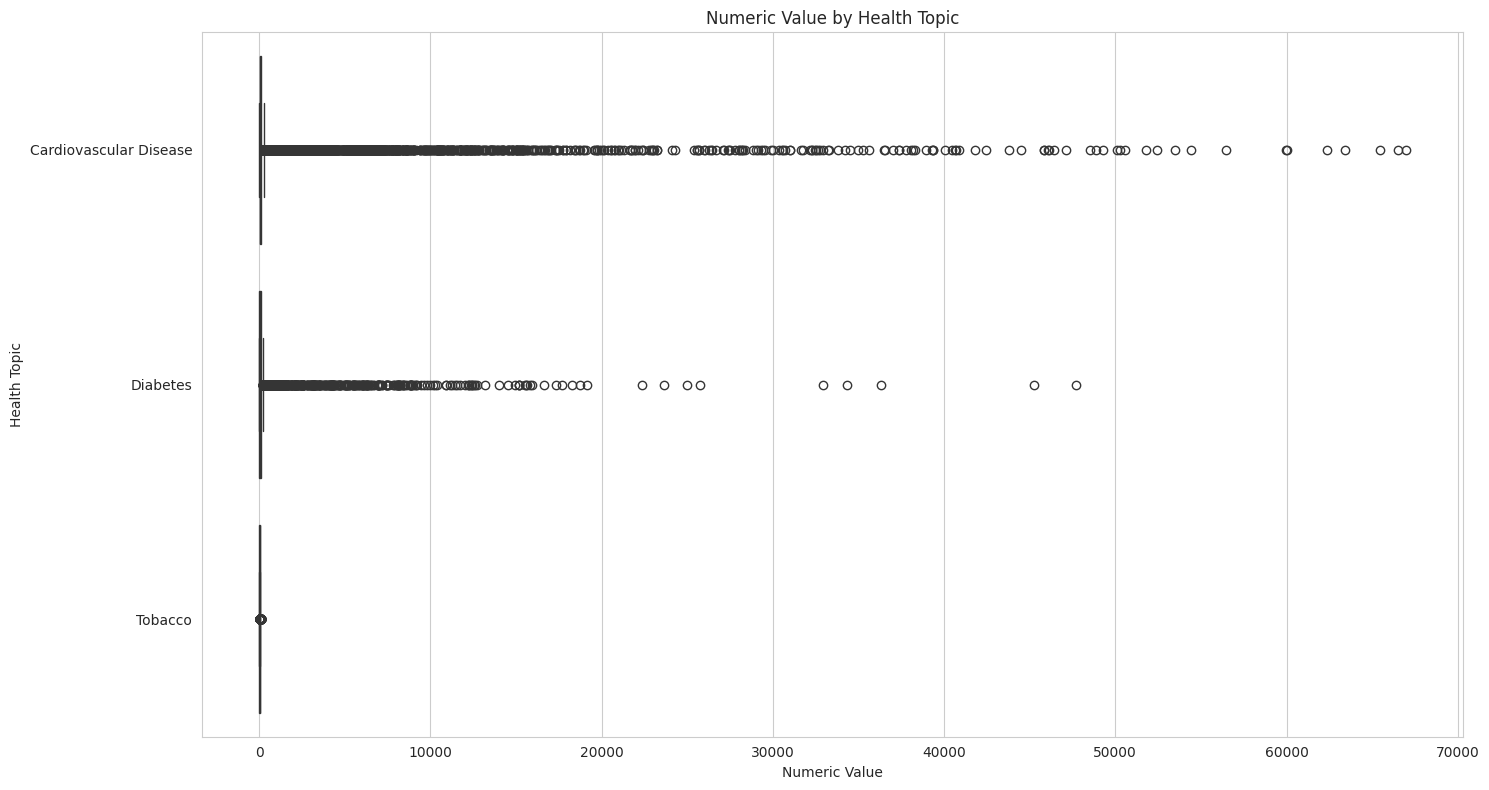

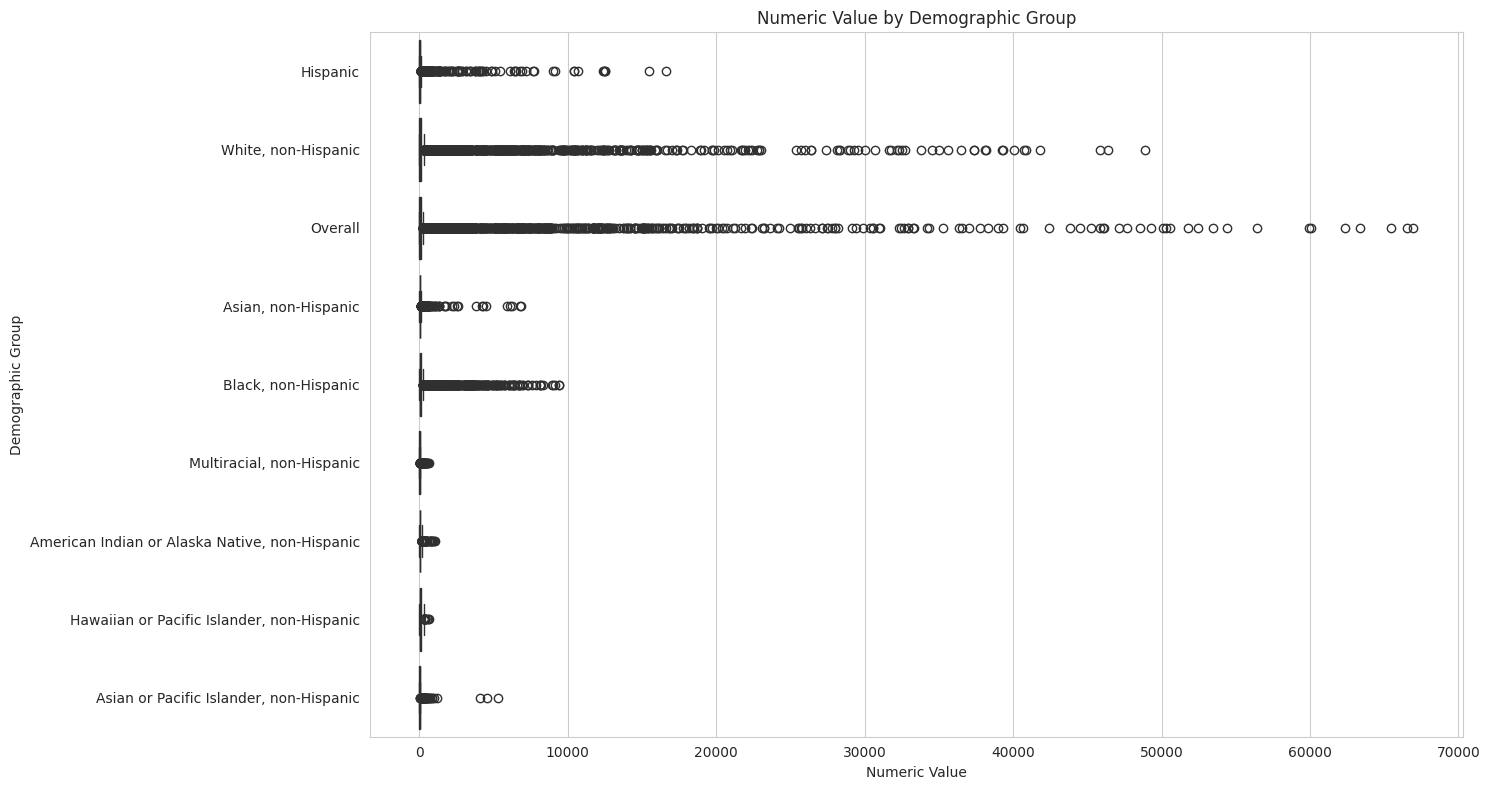

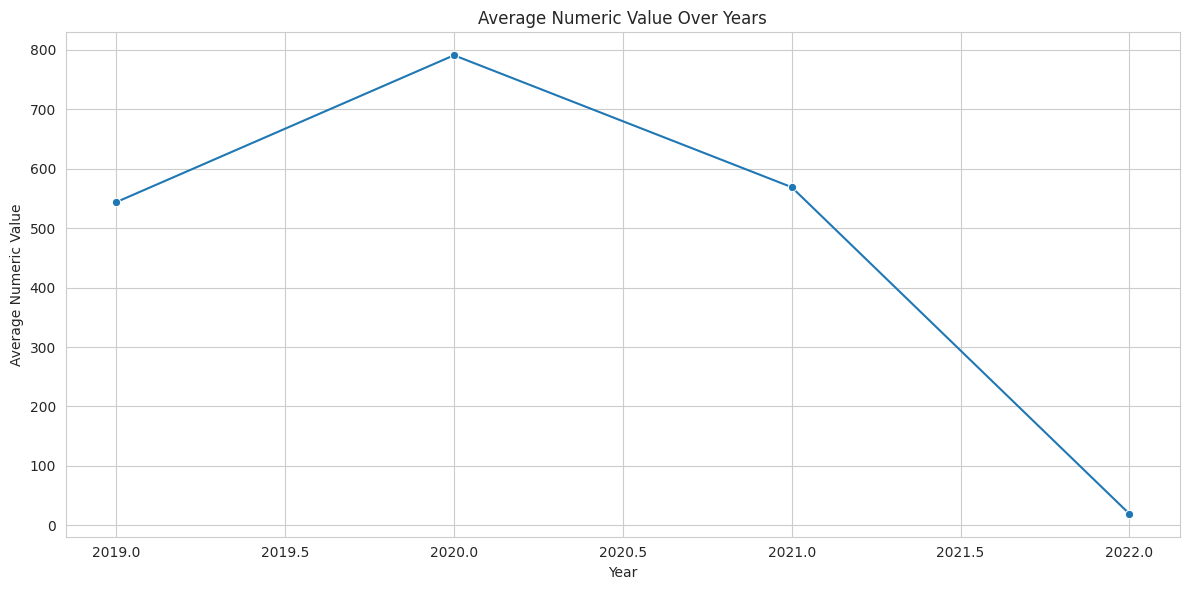

In [6]:
# 1. Relationship between numeric_value and health_topic
plt.figure(figsize=(15, 8))
sns.boxplot(x='numeric_value', y='health_topic', data=df_clean, hue='health_topic', palette='viridis', legend=False)
plt.title('Numeric Value by Health Topic')
plt.xlabel('Numeric Value')
plt.ylabel('Health Topic')
plt.tight_layout()
plt.show()

# 2. Relationship between numeric_value and demographic_group
plt.figure(figsize=(15, 8))
sns.boxplot(x='numeric_value', y='demographic_group', data=df_clean, hue='demographic_group', palette='plasma', legend=False)
plt.title('Numeric Value by Demographic Group')
plt.xlabel('Numeric Value')
plt.ylabel('Demographic Group')
plt.tight_layout()
plt.show()

# 3. Numeric Value trend over time (Year)
plt.figure(figsize=(12, 6))
# Calculate mean per year for lineplot
yearly_means = df_clean.groupby('year')['numeric_value'].mean().reset_index()
sns.lineplot(x='year', y='numeric_value', data=yearly_means, marker='o')
plt.title('Average Numeric Value Over Years')
plt.xlabel('Year')
plt.ylabel('Average Numeric Value')
plt.tight_layout()
plt.show()

### Exploring Relationships and Correlations

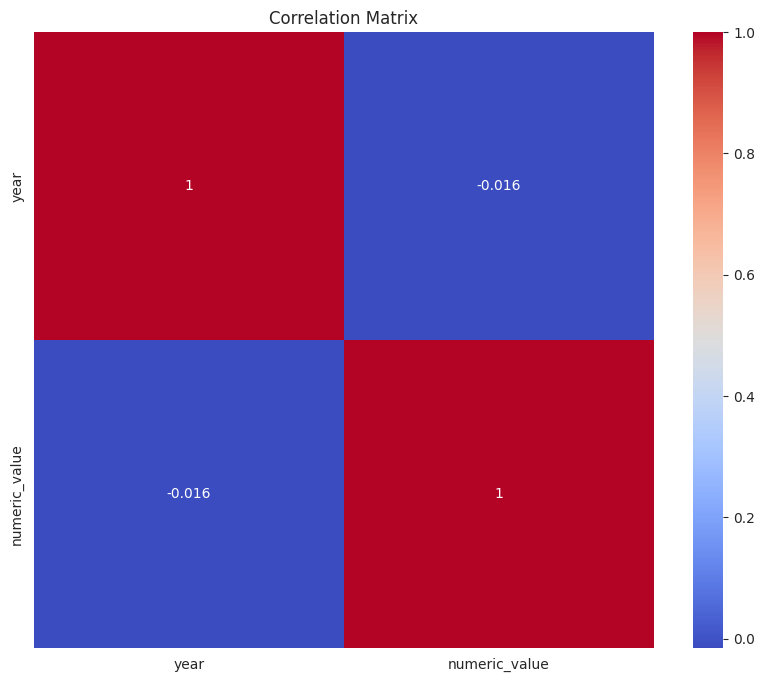

In [7]:
numeric_corr = df_clean.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix was used to identify possible linear relationships between numerical variables. Because most important predictors are categorical, correlation alone is not sufficient and additional modeling approaches may be required

The correlation heatmap showed that the numerical variables exhibited weak to moderate linear relationships. This suggests that no single numerical variable alone strongly predicts numeric_value, reinforcing the need to consider categorical variables in later analys

## Relationship & Variation Analysis
Health Topic vs. Value: The box plots show that certain health topics have consistently higher median values than others. Some categories also display a much wider horizontal spread (greater variance), indicating that overall disease burden differs considerably depending on the specific health topic being measured.

## Demographic Group vs. Value:
While demographic groups display differences in spread, their medians are clustered somewhat closer together compared to health topics.

## Sourcing the Variation:
 Based on the box plots, health_topic appears to account for much of the overall variation in numeric_value, while demographic_group also contributes, though to a slightly lesser extent.

Yearly Trends: The line plot details the annual trajectory of the average metric value. This allows us to observe if there is a systematic national rise or decline in these reported values, or if health metrics have remained relatively stable over the recorded years.

## Research Question
"To what extent do behavioral risk factors predict chronic disease outcomes across U.S. states?"

## Important Variables of Interest
To explore this question, we will focus on:

health_topic and indicator_metric (to separate the predictors from the outcomes)

demographic_group (to identify vulnerable subpopulations)

state_name (to account for geographic variation)

year (to control for annual trends)

## Analytics Objectives
Comparison: I want to compare different health topics and demographic groups to determine whether certain groups consistently experience higher chronic disease rates.

Prediction: I want to predict numeric_value using variables such as health_topic, demographic_group, and year.

## Hypotheses
Hypothesis 1: I hypothesize that behavioral risk factors such as smoking and obesity will be strongly associated with higher chronic disease rates, and that some demographic groups will consistently experience higher disease burdens than others.

Hypothesis 2: I hypothesize that there will be significant differences in numeric_value across different measurement_type categories, especially when compared for the same indicator_metric.

## Limitations and Biases
Measurement Unit Inconsistency (Critical): One primary limitation is that numeric_value represents completely different types of measurements depending on the indicator—such as prevalence percentages, raw mortality counts, and age-adjusted mortality rates. Comparing these values directly without strict filtering by indicator will produce highly misleading conclusions.

Data Source Bias: The data relies heavily on state-specific public health reporting systems, which may have inherent regional biases in what is reported and how consistently it is gathered.

Missing Data: While missing values in numeric_value were dropped, there may be implicit missingness or structural underreporting for specific combinations of health_topic and marginalized demographic_group cohorts.

Aggregation Level: The data is highly aggregated at state levels. This ecological aggregation can hide local, city-level, or county-level disparities that finer-grained data would normally reveal.

Categorical Granularity: Certain features contain high cardinality (like indicator_metric). Using these in predictive modeling will require grouping, simplified categorization, or target-encoding strategies to prevent overfitting.

In [8]:
unique_indicators = df_clean['indicator_metric'].unique()
for ind in sorted(unique_indicators):
    print(ind)

Cerebrovascular disease (stroke) mortality among all people, underlying cause
Cigarette smoking during pregnancy among women with a recent live birth
Coronary heart disease mortality among all people, underlying cause
Current cigarette smoking among adults
Current electronic vapor product use among high school students
Current smokeless tobacco use among high school students
Current tobacco use of any tobacco product among high school students
Diabetes among adults
Diabetes mortality among all people, underlying or contributing cause
Diabetic ketoacidosis mortality among all people, underlying or contributing cause
Diseases of the heart mortality among all people, underlying cause
Gestational diabetes among women with a recent live birth
High blood pressure among adults
High cholesterol among adults who have been screened
Hospitalization for heart failure as principal diagnosis, Medicare-beneficiaries aged 65 years and older
Proportion of the population protected by a comprehensive smo

In [9]:
print(df_clean['health_topic'].unique())

['Cardiovascular Disease' 'Diabetes' 'Tobacco']


In [10]:
# Filter to our two indicators of interest
smoking_df = df_clean[df_clean['indicator_metric'] == 'Current cigarette smoking among adults']
diabetes_df = df_clean[df_clean['indicator_metric'] == 'Diabetes among adults']

# Average by state (collapsing across years/demographics for a simple first pass)
smoking_by_state = smoking_df.groupby('state_name')['numeric_value'].mean().reset_index()
smoking_by_state.columns = ['state_name', 'smoking_rate']

diabetes_by_state = diabetes_df.groupby('state_name')['numeric_value'].mean().reset_index()
diabetes_by_state.columns = ['state_name', 'diabetes_rate']

# Merge into one table: one row per state
merged = pd.merge(smoking_by_state, diabetes_by_state, on='state_name')
print(f"States with both metrics: {len(merged)}")
display(merged.head(10))

States with both metrics: 54


,state_name,smoking_rate,diabetes_rate
0,Alabama,22.942500,15.506452
1,Alaska,20.648780,10.013158
2,Arizona,15.755319,13.919565
3,Arkansas,24.306667,14.227907
4,California,11.147059,12.265306
5,Colorado,14.612000,8.841026
6,Connecticut,12.197436,11.540000
7,Delaware,15.146154,13.109091
8,District of Columbia,11.274074,9.285714
9,Florida,15.776471,11.960870


Correlation coefficient (r): 0.353
P-value: 0.00888
This is statistically significant (p < 0.05)


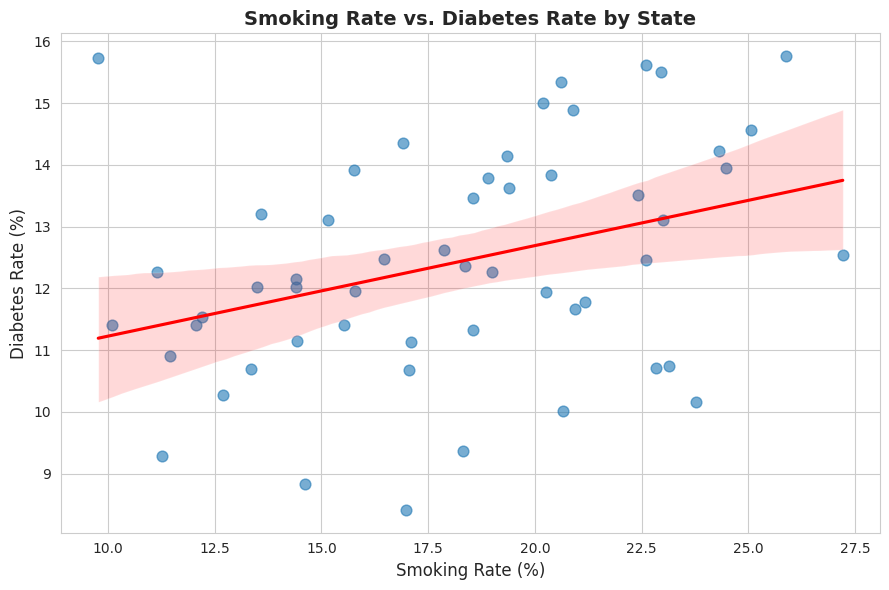

In [11]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

correlation, p_value = stats.pearsonr(merged['smoking_rate'], merged['diabetes_rate'])
print(f"Correlation coefficient (r): {correlation:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("This is statistically significant (p < 0.05)")
else:
    print("This is NOT statistically significant (p >= 0.05)")

plt.figure(figsize=(9, 6))
sns.regplot(x='smoking_rate', y='diabetes_rate', data=merged,
            scatter_kws={'alpha':0.6, 's':60}, line_kws={'color':'red'})
plt.title('Smoking Rate vs. Diabetes Rate by State', fontsize=14, fontweight='bold')
plt.xlabel('Smoking Rate (%)', fontsize=12)
plt.ylabel('Diabetes Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('smoking_diabetes_correlation.png', dpi=300, bbox_inches='tight')
plt.show()